**26/12/2025**

## Project: Cancer Detection ##

1. Implement the following algorithm, and find out which one works the best, to predict cancer
    - Malignent
    - Benign

2. Algorithmn
    - Decision Tree
    - Random Forest
    - Adaboost
    - KNN

3. Try to change the parameters of the models, hyperparameters: things you can change for the models:
    - depth of tree
    - number of estimators
    - number of neighbors

4. Find the best performance

5. Make predictions on your own defined inputs, not just the X_test

In [ ]:
# SNAS my answer as per below

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report 

In [35]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = data.data

In [4]:
data.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [5]:
from sklearn.model_selection import train_test_split

In [7]:
# input features
x = df[['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension']]

# target
y = df['target']

In [ ]:
# Question 2. Algorithm

In [8]:
# ----- Decision Tree --------

model_dt = DecisionTreeClassifier() # classification

x_train, x_test, y_train, y_test = train_test_split(x,y, random_state= 42, test_size=0.2)

model_dt.fit(x_train, y_train) # fitting here, must be numeric

y_pred_dt = model_dt.predict(x_test)

cr_dt = classification_report(y_test,y_pred_dt)

print(cr_dt)

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [27]:
# Question 3. Change the parameters of the models, depth of tree, number of estimators, number of neighbors for Decision Tree

model_dt = DecisionTreeClassifier(max_depth=5) # classification

x_train, x_test, y_train, y_test = train_test_split(x,y, random_state= 42, test_size=0.5)

model_dt.fit(x_train, y_train) # fitting here, must be numeric

y_pred_dt = model_dt.predict(x_test)

cr_dt = classification_report(y_test,y_pred_dt)

print(cr_dt)

              precision    recall  f1-score   support

           0       0.87      0.92      0.90        98
           1       0.96      0.93      0.94       187

    accuracy                           0.93       285
   macro avg       0.91      0.92      0.92       285
weighted avg       0.93      0.93      0.93       285



In [14]:
# ----- Random Forest --------

model = RandomForestClassifier(random_state=42)
model.fit(x, y)
y_pred_rf = model.predict(x_test)
print(y_pred_rf)

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0]


In [28]:
# Question 3. Change the parameters of the models, depth of tree, number of estimators, number of neighbors for Random Forest

model = RandomForestClassifier(max_depth=5, random_state=42, n_estimators=200)
model.fit(x, y)
y_pred_rf = model.predict(x_test)
print(y_pred_rf)

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0 1 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0 0 1 1 1 0 1 1 1 0 1 0 1 1 0 1 0 0
 0 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 0
 0 1 1 0 1 0 1 1 1 1 0 1 1 0 1 1 1 0 1 0 0 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 1
 0 0 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 0 1 1 0 1 0 1 0 1 0 1 1 0 1 1 1 0 1 0 1
 0 1 0 1 1 0 1 1 1 1 0 1 1 1 0 1 1 0 1 1 0 1 1 1 1 1]


In [ ]:
# ----- Adaboost --------

model_ada = AdaBoostClassifier(n_estimators=100) # classification
model_ada.fit(x_train, y_train) # fitting here, must be 
y_pred_ada = model_ada.predict(x_test)

cr_ada = classification_report(y_test,y_pred_ada)
print("----------- ADA---------\n")
print(cr_ada)

----------- ADA---------

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [30]:
# Question 3. Change the parameters of the models, depth of tree, number of estimators, number of neighbors for ADA Boost

model_ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42) # classification
model_ada.fit(x_train, y_train) # fitting here, must be 
y_pred_ada = model_ada.predict(x_test)

cr_ada = classification_report(y_test,y_pred_ada)
print("----------- ADA---------\n")
print(cr_ada)

----------- ADA---------

              precision    recall  f1-score   support

           0       0.93      0.94      0.93        98
           1       0.97      0.96      0.97       187

    accuracy                           0.95       285
   macro avg       0.95      0.95      0.95       285
weighted avg       0.95      0.95      0.95       285



In [21]:
# ----- KNN --------

model = KNeighborsClassifier(n_neighbors=5) # classification
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state= 42, test_size=0.2)
model.fit(x_train, y_train) # fitting here, must be numeric
y_pred = model.predict(x_test)

cr = classification_report(y_test,y_pred_dt)
print("---------KNN-----------\n")
print(cr)

---------KNN-----------

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [31]:
# Question 3. Change the parameters of the models, depth of tree, number of estimators, number of neighbors for KNN

model = KNeighborsClassifier(n_neighbors=5) # classification
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state= 42, test_size=0.5)
model.fit(x_train, y_train) # fitting here, must be numeric
y_pred = model.predict(x_test)

cr = classification_report(y_test,y_pred_dt)
print("---------KNN-----------\n")
print(cr)

---------KNN-----------

              precision    recall  f1-score   support

           0       0.87      0.92      0.90        98
           1       0.96      0.93      0.94       187

    accuracy                           0.93       285
   macro avg       0.91      0.92      0.92       285
weighted avg       0.93      0.93      0.93       285



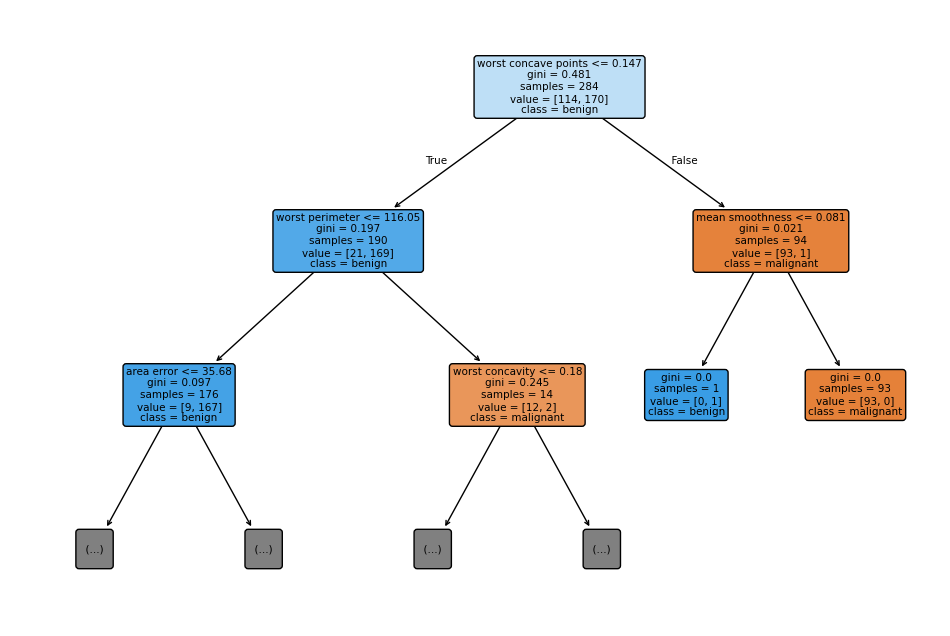

In [40]:
plt.figure(figsize=(12,8))

plot_tree(
    model_dt,
    feature_names=data.feature_names,
    class_names=data.target_names,
    max_depth=2,
    filled=True,
    rounded=True
)
plt.show()

In [ ]:
# Question 4. Find the best performance

# I don't know how

In [ ]:
# Question 5. Make predictions on your own defined inputs

# What does this means?

**29/12/2025**

In [ ]:
# Create confusion matrix